In [1]:
import numpy as np
import matplotlib.pyplot as plt
import illustris_python as il
import random
import h5py
from scipy import stats
import seaborn as sns
palette_tab10 = sns.color_palette("colorblind", 10)


In [2]:

plt.rcParams["xtick.direction"] = "in"
plt.rcParams["ytick.direction"] = "in"
plt.rc("font", family="STIXGeneral", size=18)
plt.rcParams["mathtext.fontset"] = "stix"
plt.rcParams['figure.figsize'] = (2*10/3, 4)
plt.rcParams["legend.frameon"] = False


plt.rcParams["xtick.major.size"] = 5
plt.rcParams["ytick.major.size"] = 5
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["xtick.top"] = True
plt.rcParams["ytick.right"] = True
plt.rcParams["lines.linewidth"] = 2

In [3]:
snapnum = 40

In [4]:
basePath = '/cosma7/data/dp004/dc-zhan5/TNG300-1'

In [5]:
fields = ['GroupFirstSub', "GroupSFR", "GroupMass", "GroupNsubs", 
          "GroupPos", "GroupMassType", "GroupBHMass", "Group_M_TopHat200", "Group_M_Crit200"]
header = il.groupcat.loadHeader(f"{basePath}/output", snapnum)
halos = il.groupcat.loadHalos(f"{basePath}/output", snapnum, fields=fields)

In [6]:
fields = ["SubhaloSFR", # [Msun/yr]
          "SubhaloGrNr",
         "SubhaloFlag",
         "SubhaloPos",
         "SubhaloCM", "SubhaloHalfmassRad", "SubhaloHalfmassRadType", "SubhaloMass", "SubhaloBHMass",
         "SubhaloMassType", "SubhaloVmax", "SubhaloVmaxRad"] # [10^10 Msun/h]
print(len(fields))
subhalos = il.groupcat.loadSubhalos(f"{basePath}/output", snapnum, fields=fields)
print(type(subhalos))

12


<class 'dict'>


In [7]:
mvir = np.log10(halos["Group_M_TopHat200"]*1e10)

/tmp/ipykernel_1816119/565162213.py:1: RuntimeWarning: divide by zero encountered in log10
  mvir = np.log10(halos["Group_M_TopHat200"]*1e10)


In [8]:
group_sfrs = np.log10(halos["GroupSFR"])

/tmp/ipykernel_1816119/618587702.py:1: RuntimeWarning: divide by zero encountered in log10
  group_sfrs = np.log10(halos["GroupSFR"])


In [9]:
vmax = subhalos["SubhaloVmax"]
rmax = subhalos["SubhaloVmaxRad"]

In [10]:
cent_vmax1 = subhalos["SubhaloVmax"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_vmax = np.zeros(len(mvir))
cent_vmax[halos["GroupFirstSub"]>-1] = cent_vmax1

In [11]:
cent_rmax1 = subhalos["SubhaloVmaxRad"][halos["GroupFirstSub"][halos["GroupFirstSub"]>-1]]
cent_rmax = np.zeros(len(mvir))
cent_rmax[halos["GroupFirstSub"]>-1] = cent_rmax1

In [ ]:
cent_cprox = cent_vmax/cent_rmax

/tmp/ipykernel_1816119/2104352924.py:1: RuntimeWarning: invalid value encountered in divide
  cent_cprox = cent_vmax/cent_rmax


[ 0.43249878  1.96619082  2.93497483  4.27317897 40.41873591]


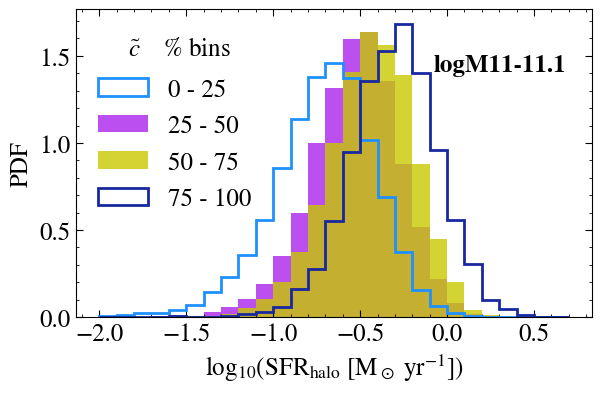

In [13]:
bins=np.arange(-2, 0.8, 0.1)

color_list = plt.rcParams['axes.prop_cycle'].by_key()['color'][:3] + plt.rcParams['axes.prop_cycle'].by_key()['color'][5:]
#color_list = ["#23AAEB","#AC23EB","#F5AD55","#18289F"]
color_list = ["#23AAEB","#AC23EB","#c8c800","#18289F"]
#color_list = palette_tab10[5:]
#color_list = ["navy"] + ["lightpink"] + palette_tab10[4:]
color_list = ["green","#AC23EB","#c8c800","#18289F"]
color_list = ["dodgerblue", "#AC23EB", "#c8c800","#18289F"]
logM = 11
mask2 = (mvir> logM) & (mvir < logM+0.1)
median = np.nanmedian(cent_cprox[mask2])
mask_high = cent_cprox[mask2] > median
mask_low = cent_cprox[mask2] < median

percentile_list = [0, 25, 50, 75, 100]
percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)

print(percentiles)
masks = []
for i, percentile in enumerate(percentiles[:4]):
    mask = (cent_cprox[mask2] > percentiles[i]) & (cent_cprox[mask2] < percentiles[i+1])
    masks.append(mask)
    if (i == 1) or (i == 2):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=0.8, color=color_list[i])# facecolor="none", edgecolor=color_list[i])
    elif (i == 0) or (i == 3):
        plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step', linewidth=2)# facecolor="none", edgecolor=color_list[i])


# plt.hist(cent_sfr[mask2][mask_high], bins=bins, density=True, label="above median conc", alpha=0.5)
# plt.hist(cent_sfr[mask2][mask_low],bins=bins, density=True, label="below median conc", alpha=0.5)
plt.legend(loc="upper left", bbox_to_anchor=(0,0.85))
plt.xlabel(r'log$_{10}$(SFR$_{\rm halo}$ [M$_\odot$ yr$^{-1}$])', fontsize=18)
plt.ylabel(f"PDF", fontsize=18)
logM_name = f"logM{logM}-{np.round(logM+0.1,1)}"
plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

#plt.annotate(f"{logM_name}", (0.95,0.8), xycoords="axes fraction", ha="right", weight="bold")

plt.annotate(r"$\tilde{c}\quad$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")

plt.savefig("../figures/hist_logM11-11.1_conc_proxy.pdf", format="pdf", bbox_inches="tight")

In [14]:
logMs = np.arange(11,14, 0.1)
nbins = len(logMs)


new_medians_arr = np.zeros((4,nbins), dtype=float)
new_iqrs_arr = np.zeros((4,nbins), dtype=float)

orig_iqrs = []
orig_medians = []

nhalos = []

for ibin, logM in enumerate(logMs):
    mask2 = (mvir> logM) & (mvir < logM+0.1)
    nhalos.append(np.sum(mask2))
    percentile_list = [0, 25, 50, 75, 100]
    percentiles = np.nanpercentile(cent_cprox[mask2], percentile_list)
    
    ps = np.nanpercentile(group_sfrs[mask2], q=[25,75])
    iqr = ps[1] - ps[0]
    orig_iqrs.append(iqr)
    
    med = np.nanpercentile(group_sfrs[mask2], q=[50])
    orig_medians.append(med)
    
    iqrs = []
    sigmas = []
    new_medians = []
    for ip, percentile in enumerate(percentiles[:4]):
        mask = (cent_cprox[mask2] > percentiles[ip]) & (cent_cprox[mask2] < percentiles[ip+1]) #& (group_sfrs[mask2] > -5)
        masks.append(mask)
        #plt.hist(group_sfrs[mask2][mask], bins=bins, density=True, label=f"{percentile_list[i]} - {percentile_list[i+1]}", alpha=1, color=color_list[i],histtype='step')# facecolor="none", edgecolor=color_list[i])
        ps = np.nanpercentile(group_sfrs[mask2][mask], q=[25,75])
        #print(logM)
        #print(ps)
        if len(group_sfrs[mask2][mask]) > 4:
            iqr = ps[1] - ps[0]
            new_iqrs_arr[ip][ibin] = iqr
        else:
            new_iqrs_arr[ip][ibin] = np.nan
        #iqr = ps[1] - ps[0]
        iqrs.append(iqr)
        #print(np.nanstd(group_sfrs[mask2][mask]))
        med = np.nanmedian(group_sfrs[mask2][mask])
        new_medians.append(med)
        new_medians_arr[ip][ibin] = med
        new_iqrs_arr[ip][ibin] = iqr

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1816119/1504790448.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')


(10.9, 14.1)

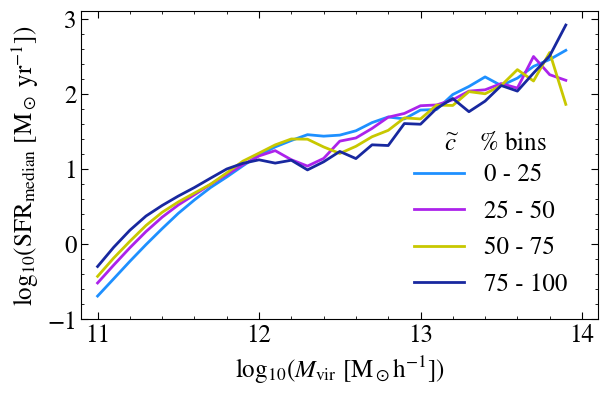

In [15]:
for ip in range(4):
    plt.plot(logMs, new_medians_arr[ip],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip],linewidth=2)
    

#plt.plot(logMs, orig_medians, color=palette_tab10[3] , linestyle="dashed")
    
plt.legend(loc="lower left", bbox_to_anchor=(0.6,0))
plt.annotate(r"$\widetilde{c}\quad$ % bins", (0.9,0.55), xycoords="axes fraction", ha="right")

#plt.annotate("Median of each"+ "\n" + r"$\widetilde{V}_{\rm max}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_{\mathrm{vir}}$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-1,3.1)
plt.xlim(10.9,14.1)
#plt.savefig("../figures/median_conc_proxy.pdf", format="pdf", bbox_inches="tight")

<>:12: SyntaxWarning: invalid escape sequence '\m'
<>:12: SyntaxWarning: invalid escape sequence '\m'
/tmp/ipykernel_1816119/3137429907.py:12: SyntaxWarning: invalid escape sequence '\m'
  plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')


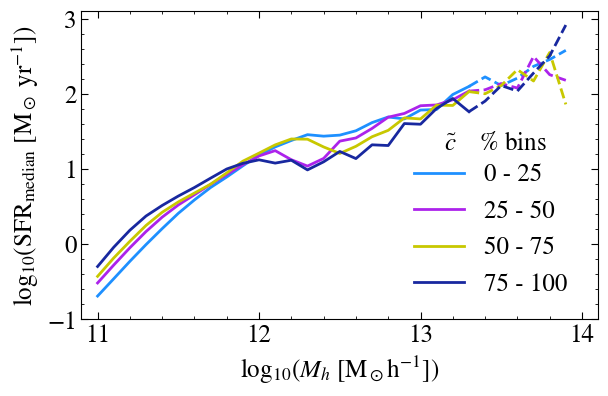

In [16]:
index = nhalos.index(101)
for ip in range(4):
    plt.plot(logMs[:index+1], new_medians_arr[ip][:index+1],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip])
    plt.plot(logMs[index:], new_medians_arr[ip][index:], color=color_list[ip], linestyle="dashed")

    
plt.legend(loc="lower left", bbox_to_anchor=(0.6,0))
plt.annotate(r"$\tilde{c}\quad$ % bins", (0.9,0.55), xycoords="axes fraction", ha="right")

#plt.annotate("Median of each"+ "\n" + r"$M_{\rm sat}$ bin", (0.1,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_h$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('log$_{10}$(SFR$_{\mathrm{median}}$ [M$_\odot$ yr$^{-1}$])')
plt.ylim(-1,3.1)
plt.xlim(10.9,14.1)

plt.savefig("../figures/median_conc_proxy_w_dashed.pdf", format="pdf", bbox_inches="tight")

<>:18: SyntaxWarning: invalid escape sequence '\o'
<>:18: SyntaxWarning: invalid escape sequence '\o'
/tmp/ipykernel_1816119/3843970812.py:18: SyntaxWarning: invalid escape sequence '\o'
  plt.ylabel('IQR of log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')


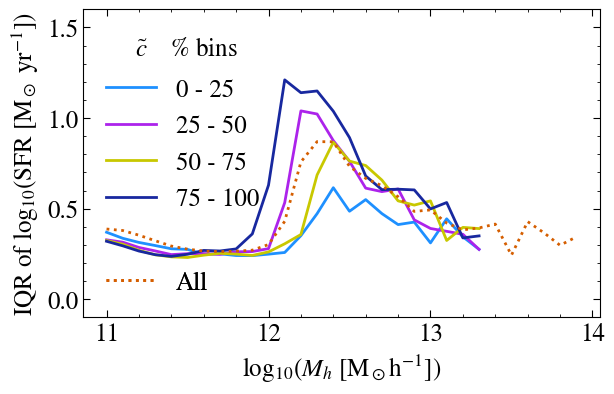

In [ ]:

for ip in range(4):
    plt.plot(logMs[:index+1], new_iqrs_arr[ip][:index+1],label=f"{percentile_list[ip]} - {percentile_list[ip+1]}", color=color_list[ip], linewidth=2)

    

plt.plot(logMs, orig_iqrs, color=palette_tab10[3] , linestyle="dotted", label="All")

ax = plt.gca()
handles, labels = ax.get_legend_handles_labels()
leg = ax.legend(handles=handles[:-1],loc="upper left", bbox_to_anchor=(0,0.85))
ax.add_artist(leg)
leg = ax.legend(handles=handles[-1:], loc="lower left")
ax.add_artist(leg)  

plt.annotate(r"$\tilde{c}\quad$ % bins", (0.3,0.85), xycoords="axes fraction", ha="right")
#plt.annotate("IQR of each"+ "\n" + r"$\widetilde{V}_{\rm max}$ bin", (0.7,0.7), xycoords="axes fraction")
plt.xlabel(r"$\rm log_{10} $($M_h$ $\rm[M_\odot h^{-1}$])")
plt.ylabel('IQR of log$_{10}$(SFR [M$_\odot$ yr$^{-1}$])')
plt.ylim(-0.1,1.6)
plt.savefig("../figures/iqr_conc_proxy.pdf", format="pdf", bbox_inches="tight")